In [1]:
import itertools
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Загружаем данные
data = pd.read_csv('D:/Data_env/cells/results.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   File Name            14 non-null     object 
 1   Total Pixels         14 non-null     int64  
 2   Mask Pixels          14 non-null     int64  
 3   Coverage Percentage  14 non-null     float64
 4   Objects Detected     14 non-null     int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 688.0+ bytes


In [3]:
# Считаем границы для каждой группы
grouped = data.groupby('File Name')['Coverage Percentage']
q1 = grouped.transform('quantile', 0.25)
q3 = grouped.transform('quantile', 0.75)
iqr = q3 - q1

# Фильтруем таблицу
is_inside = (data['Coverage Percentage'] >= (q1 - 1.5 * iqr)) &\
            (data['Coverage Percentage'] <= (q3 + 1.5 * iqr))
data = data[is_inside].reset_index(drop=True)

# Выводим результат
print('Размеры выборок:\n' + data['File Name'].value_counts().to_string(header=False, dtype=False))

Размеры выборок:
Glycyrrhiza_01    7
Glycyrrhiza_04    7


In [4]:
groups = sorted(data['File Name'].unique().tolist())
all_values = data['Coverage Percentage'].values
group_labels = data['File Name'].values

# Задаем параметры симуляции
rng = np.random.default_rng(42)    # фиксируем сид 
n = 100000    # общее количество симуляций
batch_size = 5000    # размер батча

# Записываем все возможные пары групп
pairs = list(itertools.combinations(groups, 2))
raw_p_values = {}

# Запускаем перестановочный тест для каждой пары
for gr1, gr2 in pairs:
    # Выделяем подвыборку для текущих двух групп
    mask = (group_labels == gr1) | (group_labels == gr2)
    pair_values = all_values[mask]
    pair_labels = group_labels[mask]
    
    n_control = np.sum(pair_labels == gr1)
    n_test = np.sum(pair_labels == gr2)
    
    # Считаем базовую разницу средних
    base_diff = np.abs(pair_values[pair_labels == gr1].mean() - pair_values[pair_labels == gr2].mean())
    
    success_count = 0
    
    # Цикл симуляций батчами
    for _ in range(n // batch_size):
        sim_indices = np.array([rng.permutation(len(pair_values)) for _ in range(batch_size)])
        
        ctrl_idx = sim_indices[:, :n_control]
        test_idx = sim_indices[:, n_control : n_control + n_test]
        
        ctrl_means = pair_values[ctrl_idx].mean(axis=1)
        test_means = pair_values[test_idx].mean(axis=1)
        sim_diffs = np.abs(ctrl_means - test_means)
        
        success_count += np.sum(sim_diffs >= base_diff)
    
    # Записываем сырое p-value для этой пары
    p_val = (success_count + 1) / (n + 1)
    raw_p_values[f"{gr1} vs {gr2}"] = p_val

# Делаем поправку на множественные сравнения
p_vals_list = list(raw_p_values.values())
labels_list = list(raw_p_values.keys())
reject, corrected_p_vals, _, _ = multipletests(p_vals_list, alpha=0.05, method='holm')    # метод Холма

# Выводим результат
results = pd.DataFrame({'Сравнение': labels_list,
                        'Сырое p-value': p_vals_list,
                        'Поправленное p-value': corrected_p_vals,
                        'Отвергаем H0 (Различия значимы)': reject})

print(results.to_string(index=False))

                       Сравнение  Сырое p-value  Поправленное p-value  Отвергаем H0 (Различия значимы)
Glycyrrhiza_01 vs Glycyrrhiza_04       0.299077              0.299077                            False


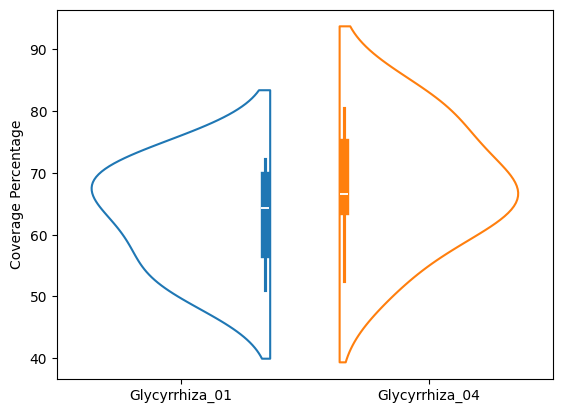

In [5]:
# Представляем результат в виде графика
sns.violinplot(data=data, 
               x='File Name', 
               y='Coverage Percentage', 
               hue='File Name',
               fill=False,
               split=True, gap=.1,).set_xlabel('');

---